# SA-PINN optimizer study — results

*Results notebook for the Scientific ML chapter — ECEN 744 final project.*

This notebook **loads the committed result CSVs** from my final project and replots the
optimizer comparison across four PDE benchmarks. It does *not* retrain anything — training
those models requires the project's vendored SciPy patch (see the caveat at the bottom).

**Credit.** The final project is joint work with a project teammate, built on **Levi
McClenny's** public [SA-PINN codebase](https://github.com/levimcclenny/SA-PINNs) (the
self-adaptive weighting and the training scaffolding are his; see the
[SA-PINN page](../sa-pinns.md)). The optimizer variants studied here come from published
work — the meta-learned optimizer (Bihlo, 2023) and the self-scaled quasi-Newton methods
(Urbán et al., 2025).

**Data provenance.** The CSVs in `data/` are copied from
`~/Projects/school/tamu-grad/ECEN744-FinalProject-SA-PINNs/Results/`
(`results_summary.csv` per run). The Burgers loss curves are the committed
`training_loss.csv` / `lbfgs_loss.csv`, **downsampled to every 25th iteration** so the
whole data folder stays ~120 KB; the full-resolution histories live in the source repo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- book dataviz palette (validated categorical + chrome) ---
BLUE, YELLOW, GREEN, MAGENTA = "#2a78d6", "#eda100", "#008300", "#e87ba4"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.titlesize": 12, "text.color": INK, "axes.labelcolor": INK,
    "axes.titlecolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "grid.color": GRID,
    "legend.frameon": False, "figure.dpi": 110,
})

# optimizer identity -> fixed categorical hue (never cycled)
OPT_ORDER = ["L-BFGS", "Learnable", "SSBFGS", "SSBroyden2"]
OPT_COLOR = {"L-BFGS": BLUE, "Learnable": YELLOW, "SSBFGS": GREEN, "SSBroyden2": MAGENTA}
PDE_ORDER = ["Burgers", "Helmholtz", "Allen-Cahn", "Kuramoto-Sivashinsky"]

## 1. Load the summary table

One row per (PDE, optimizer) run, at the shared 10k-phase-1 / 10k-phase-2 budget.
`error_u` is the relative $L^2$ error $\lVert u_\text{pred}-u_\text{exact}\rVert_2 /
\lVert u_\text{exact}\rVert_2$; "L-BFGS" is the SA-PINN baseline (Adam phase 1 + L-BFGS
phase 2).

In [2]:
df = pd.read_csv("data/results_summary_all.csv")
df["optimizer"] = pd.Categorical(df["optimizer"], categories=OPT_ORDER, ordered=True)
df["pde"] = pd.Categorical(df["pde"], categories=PDE_ORDER, ordered=True)
df = df.sort_values(["pde", "optimizer"]).reset_index(drop=True)
df[["pde", "optimizer", "error_u", "final_lbfgs_loss"]]

,pde,optimizer,error_u,final_lbfgs_loss
0,Burgers,L-BFGS,0.001619,1.968253e-03
1,Burgers,Learnable,0.001082,1.623849e-03
2,Burgers,SSBFGS,0.000031,1.493991e-05
3,Burgers,SSBroyden2,0.000043,1.679504e-05
4,Helmholtz,L-BFGS,0.005649,1.764529e-03
5,Helmholtz,Learnable,0.005572,1.432885e-03
6,Helmholtz,SSBFGS,0.000126,1.361428e-06
7,Helmholtz,SSBroyden2,0.000137,8.759129e-07
8,Allen-Cahn,L-BFGS,0.097724,1.913002e-03
9,Allen-Cahn,Learnable,0.260713,3.113106e-01


## 2. Relative $L^2$ error across PDEs

The headline plot: lower is better, log scale. On Burgers, Helmholtz, and KS the
self-scaled quasi-Newton methods (green/magenta) sit one to four orders of magnitude below
the Adam/L-BFGS baseline (blue). **Allen–Cahn is the exception** — and note it has no
committed SSBFGS run, so only three bars appear there.

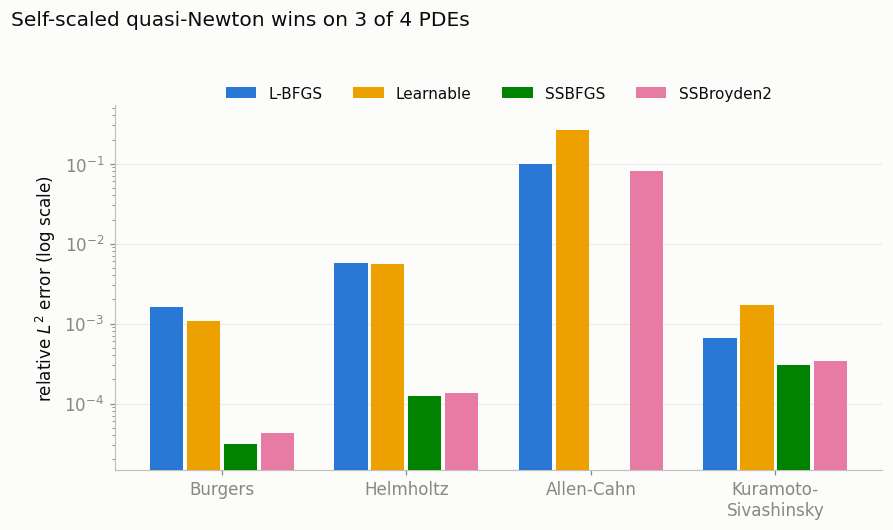

In [3]:
pivot = df.pivot_table(index="pde", columns="optimizer", values="error_u", observed=True)

fig, ax = plt.subplots(figsize=(9.0, 4.8))
n = len(OPT_ORDER); gw = 0.8; bw = gw / n
xbase = np.arange(len(PDE_ORDER))
for j, opt in enumerate(OPT_ORDER):
    xs, ys = [], []
    for i, pde in enumerate(PDE_ORDER):
        v = pivot.loc[pde, opt] if opt in pivot.columns else np.nan
        if pd.notna(v):
            xs.append(xbase[i] - gw/2 + bw*(j+0.5)); ys.append(v)
    ax.bar(xs, ys, width=bw*0.9, color=OPT_COLOR[opt], label=opt, zorder=3)
ax.set_yscale("log"); ax.set_ylabel(r"relative $L^2$ error (log scale)")
ax.set_xticks(xbase); ax.set_xticklabels(["Burgers", "Helmholtz", "Allen-Cahn", "Kuramoto-\nSivashinsky"])
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(True, axis="y", alpha=0.6); ax.set_axisbelow(True); ax.margins(y=0.08)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.09), fontsize=10)
fig.suptitle("Self-scaled quasi-Newton wins on 3 of 4 PDEs", x=0.02, ha="left")
fig.subplots_adjust(top=0.80); plt.show()

## 3. Burgers: the two training phases

Where does the advantage come from? Phase 1 (first-order: Adam or the learnable
optimizer) is a noisy saddle-point ride for every variant. The separation happens in
**phase 2**: standard L-BFGS and the learnable variant crawl down to ~$10^{-3}$, while
the self-scaled quasi-Newton methods plunge to ~$10^{-5}$ and hit SciPy's precision-loss
termination in about a thousand iterations.

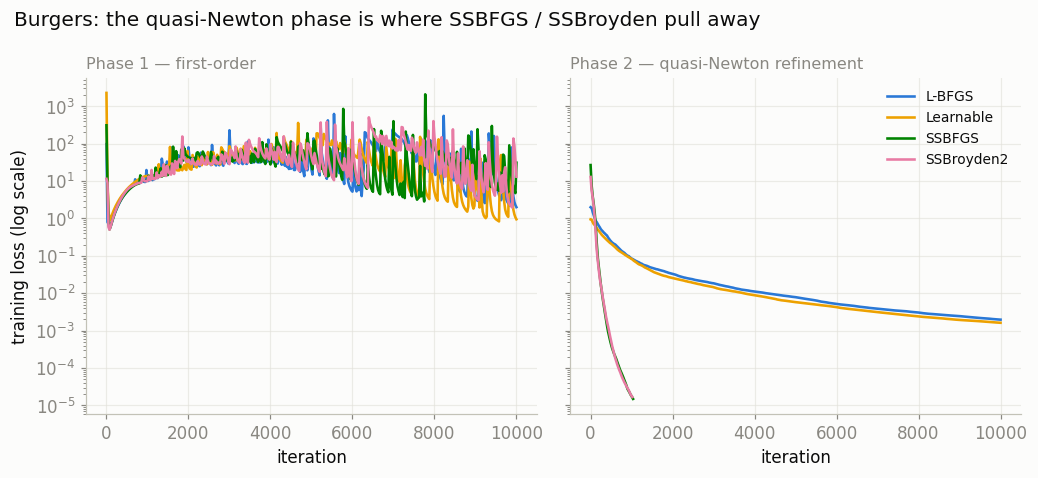

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 4.4), sharey=True)
for opt in OPT_ORDER:
    p1 = pd.read_csv(f"data/burgers_phase1_{opt}.csv")
    ax1.plot(p1["epoch"], p1["total_loss"], color=OPT_COLOR[opt], lw=1.7, label=opt)
    p2 = pd.read_csv(f"data/burgers_phase2_{opt}.csv")
    ax2.plot(p2["step"], p2["loss"], color=OPT_COLOR[opt], lw=1.7, label=opt)
for ax in (ax1, ax2):
    ax.set_yscale("log"); ax.set_xlabel("iteration")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.grid(True, alpha=0.6); ax.set_axisbelow(True)
ax1.set_ylabel("training loss (log scale)")
ax1.set_title("Phase 1 — first-order", loc="left", fontsize=10.5, color=MUTED)
ax2.set_title("Phase 2 — quasi-Newton refinement", loc="left", fontsize=10.5, color=MUTED)
ax2.legend(fontsize=9, loc="upper right")
fig.suptitle("Burgers: the quasi-Newton phase is where SSBFGS / SSBroyden pull away",
             x=0.02, ha="left")
plt.tight_layout(); plt.show()

## 4. Best optimizer per benchmark

A compact leaderboard: for each PDE, which configuration reached the lowest relative
$L^2$ error, and by how much it beat the L-BFGS baseline.

In [5]:
rows = []
for pde in PDE_ORDER:
    sub = df[df["pde"] == pde]
    base = sub.loc[sub["optimizer"] == "L-BFGS", "error_u"]
    best = sub.loc[sub["error_u"].idxmin()]
    base_v = float(base.iloc[0]) if len(base) else np.nan
    rows.append({
        "PDE": pde,
        "best optimizer": str(best["optimizer"]),
        "best rel. L2": f"{best['error_u']:.2e}",
        "baseline (L-BFGS)": f"{base_v:.2e}",
        "improvement": f"{base_v / best['error_u']:.0f}x" if base_v == base_v else "-",
    })
pd.DataFrame(rows)

,PDE,best optimizer,best rel. L2,baseline (L-BFGS),improvement
0,Burgers,SSBFGS,3.09e-05,1.62e-03,52x
1,Helmholtz,SSBFGS,1.26e-04,5.65e-03,45x
2,Allen-Cahn,SSBroyden2,8.01e-02,9.77e-02,1x
3,Kuramoto-Sivashinsky,SSBFGS,3.04e-04,6.59e-04,2x


## What the results say

- **Curvature-aware optimization is the lever.** Holding architecture, loss, and the
  self-adaptive weights fixed, just swapping the phase-2 optimizer for a self-scaled
  quasi-Newton method (SSBFGS / SSBroyden) cuts relative $L^2$ error by 40–52× on Burgers
  and Helmholtz, and drives the KS residual three to four orders of magnitude lower.
- **The learnable meta-optimizer didn't generalize.** It modestly beat the baseline on
  Burgers/Helmholtz but underperformed badly on Allen–Cahn and KS — a pretrained,
  frozen optimizer doesn't transfer cleanly to new PDEs.
- **Allen–Cahn resists.** The cubic-reaction stiffness is the one case where the QN
  advantage evaporates: SSBFGS roughly matches the baseline and SSBroyden underperforms it.

> **Reproducibility caveat (read before re-running).** The numbers here are our own
> reproduced runs, not a byte-for-byte replay of the published SA-PINN results — we could
> not perfectly recreate the original environment, so the L-BFGS row is *our* reference,
> not the paper's. Re-running the **quasi-Newton** variants requires replacing your local
> `scipy/optimize/_minimize.py` and `_optimize.py` with the patched files vendored in the
> repo's `Optimizers/` folder (self-scaled BFGS/Broyden from Urbán et al., 2025); stock
> SciPy silently ignores those options. The Adam and Learnable variants run on the stock
> stack (TensorFlow 2.15.1 / SciPy 1.12.0). Exact per-PDE commands and the patch
> instructions are in the repo `README.md`
> (`~/Projects/school/tamu-grad/ECEN744-FinalProject-SA-PINNs/README.md`).
